<a href="https://colab.research.google.com/github/Dragnel25/timeseriesdoan/blob/main/notebooks_01_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- 5 DÒNG DỮ LIỆU ĐẦU TIÊN ---


,Load
Datetime,
2004-10-01 01:00:00,12379.0
2004-10-01 02:00:00,11935.0
2004-10-01 03:00:00,11692.0
2004-10-01 04:00:00,11597.0
2004-10-01 05:00:00,11681.0


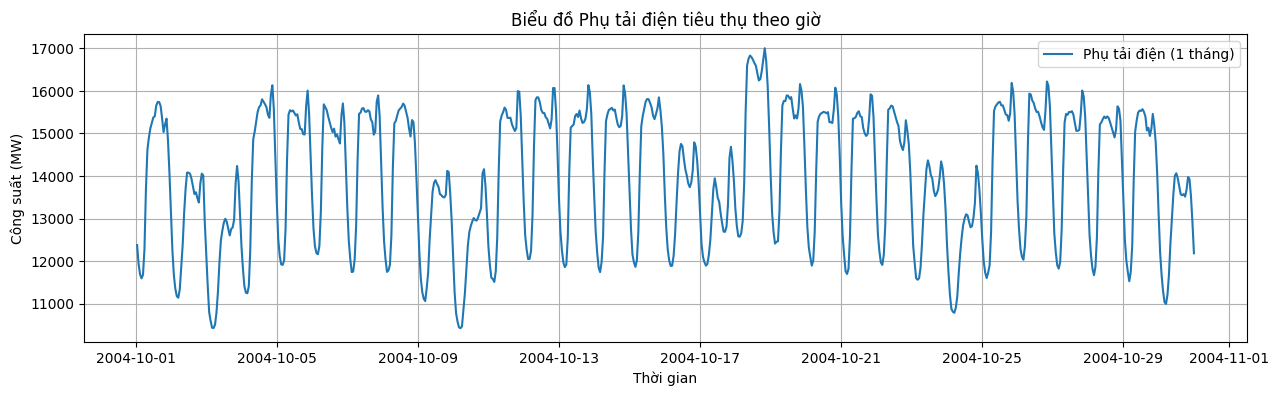


--- TOP CÁC CHU KỲ MÙA VỤ NỔI BẬT NHẤT ---
Top 1: Chu kỳ = 24.00 giờ | Biên độ = 1687.75
Top 2: Chu kỳ = 4332.00 giờ | Biên độ = 1423.99
Top 3: Chu kỳ = 168.00 giờ | Biên độ = 891.21
Top 4: Chu kỳ = 12.00 giờ | Biên độ = 782.83
Top 5: Chu kỳ = 24.07 giờ | Biên độ = 723.78


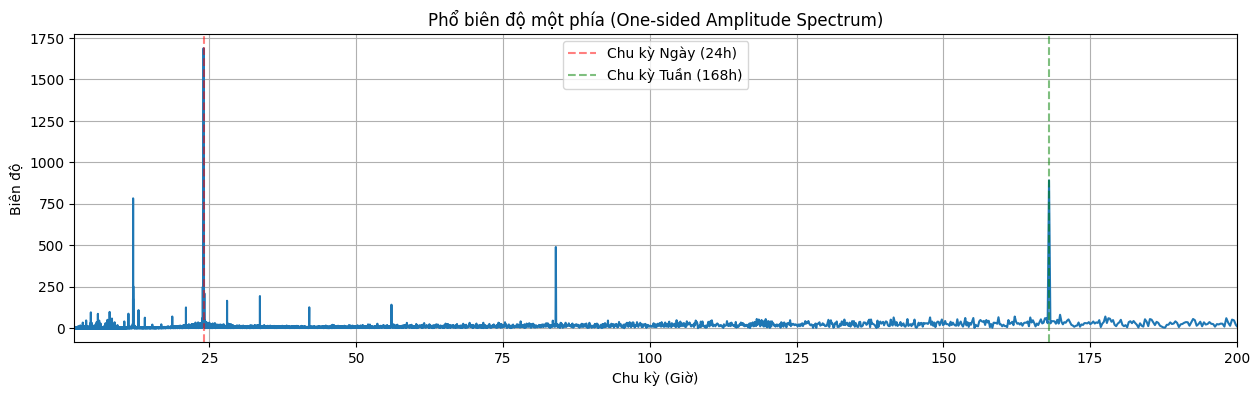

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import detrend
from scipy.fft import rfft, rfftfreq

# 1. ĐỌC DỮ LIỆU
# GHI CHÚ: Dán cái link Raw cậu vừa copy vào giữa 2 dấu ngoặc kép bên dưới
url = "https://raw.githubusercontent.com/Dragnel25/timeseriesdoan/refs/heads/main/data/raw/AEP_hourly.csv"

# Nếu cậu xài Cách 2 (up file .zip), hãy dùng dòng này thay thế:
# df = pd.read_csv(url, compression='zip')
df = pd.read_csv(url)

# Đổi tên cột cho chuẩn
df.columns = ['Datetime', 'Load']
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime').reset_index(drop=True)

# 2. TIỀN XỬ LÝ (Xử lý Missing & Resample để đảm bảo khoảng lấy mẫu đều)
df = df.drop_duplicates(subset='Datetime', keep='last')
df = df.set_index('Datetime')
df = df.resample('h').interpolate(method='linear')

print("--- 5 DÒNG DỮ LIỆU ĐẦU TIÊN ---")
display(df.head())

# Vẽ đồ thị 1 tháng đầu để quan sát dao động
plt.figure(figsize=(15, 4))
plt.plot(df.index[:24*30], df['Load'][:24*30], label='Phụ tải điện (1 tháng)')
plt.title("Biểu đồ Phụ tải điện tiêu thụ theo giờ")
plt.xlabel("Thời gian")
plt.ylabel("Công suất (MW)")
plt.legend()
plt.grid(True)
plt.show()

# 3. TRÍCH XUẤT ĐẶC TRƯNG FOURIER (Xác định chu kỳ ngày & tuần)
# Khử xu hướng (detrend) trước khi dùng FFT để đỉnh phổ không bị lấn át
x_detrended = detrend(df['Load'].dropna().values)
N = len(x_detrended)
dt = 1.0 # 1 giờ
fs = 1.0 / dt

# Tính Real FFT
X = rfft(x_detrended)
freqs = rfftfreq(N, d=dt)

# Chuẩn hóa phổ một phía (Không nhân đôi DC và Nyquist)
amplitude = np.abs(X) / N
if N % 2 == 0:
    amplitude[1:-1] *= 2
else:
    amplitude[1:] *= 2

# Loại bỏ tần số 0 (DC) vì không có chu kỳ hữu hạn
valid = freqs > 0
freqs_v = freqs[valid]
amplitude_v = amplitude[valid]
periods_v = 1.0 / freqs_v

# Tìm các đỉnh nổi bật nhất
order = np.argsort(amplitude_v)[::-1]
top_k = 5

print("\n--- TOP CÁC CHU KỲ MÙA VỤ NỔI BẬT NHẤT ---")
for i in range(top_k):
    k = order[i]
    print(f"Top {i+1}: Chu kỳ = {periods_v[k]:.2f} giờ | Biên độ = {amplitude_v[k]:.2f}")

# Vẽ phổ biên độ FFT
plt.figure(figsize=(15, 4))
plt.plot(periods_v, amplitude_v)
plt.xlim(2, 200) # Chỉ quan sát chu kỳ từ 2 đến 200 giờ
plt.title("Phổ biên độ một phía (One-sided Amplitude Spectrum)")
plt.xlabel("Chu kỳ (Giờ)")
plt.ylabel("Biên độ")
plt.axvline(24, color='r', linestyle='--', alpha=0.5, label='Chu kỳ Ngày (24h)')
plt.axvline(168, color='g', linestyle='--', alpha=0.5, label='Chu kỳ Tuần (168h)')
plt.legend()
plt.grid(True)
plt.show()